<a href="https://colab.research.google.com/github/pc11837/Classification/blob/main/spam_ham_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("spam_email.csv")

print(df.head())
print(df.info())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode target
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

X = df['Message']
y = df['Category']

# Text to numeric
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 74098 stored elements and shape (5572, 8709)>
  Coords	Values
  (0, 3567)	0.14786475068980162
  (0, 8080)	0.2300034410835773
  (0, 4370)	0.32645117023873077
  (0, 5954)	0.25533539230157154
  (0, 2334)	0.25281395947472957
  (0, 1313)	0.24417482890859654
  (0, 5567)	0.156366230319576
  (0, 4110)	0.10707657674366398
  (0, 1763)	0.2757872678027423
  (0, 3651)	0.1803318063070826
  (0, 8544)	0.22081883351949952
  (0, 4497)	0.2757872678027423
  (0, 1761)	0.31163292870610654
  (0, 2057)	0.2757872678027423
  (0, 7690)	0.15550627816331297
  (0, 3611)	0.15304155020494287
  (0, 1079)	0.32645117023873077
  (0, 8320)	0.18240101628302693
  (1, 5534)	0.2718944069420321
  (1, 4533)	0.4083258549263009
  (1, 4338)	0.5236804332035243
  (1, 8446)	0.43162957585464123
  (1, 5563)	0.5466243141314314
  (2, 4110)	0.07913674465201573
  (2, 3369)	0.11310793123981583
  :	:
  (5570, 4241)	0.12205359146631063
  (5570, 8367)	0.18796551984834134
  (5570, 10

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {

"Naive Bayes": MultinomialNB(),

"Logistic Regression": LogisticRegression(max_iter=1000),

"SVM": SVC(probability=True),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier()

}

results = {}

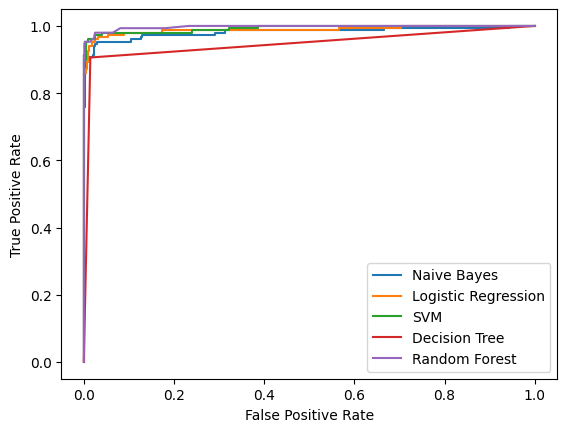

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    results[name] = (acc, auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr,tpr,label=name)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
for model in results:

    print(model)

    print("Accuracy:",results[model][0])

    print("AUC:",results[model][1])

    print()

Naive Bayes
Accuracy: 0.9650224215246637
AUC: 0.9811163449914545

Logistic Regression
Accuracy: 0.9623318385650225
AUC: 0.9879319688190421

SVM
Accuracy: 0.9829596412556054
AUC: 0.9927049897869857

Decision Tree
Accuracy: 0.9748878923766816
AUC: 0.9457737574165936

Random Forest
Accuracy: 0.9775784753363229
AUC: 0.9970159934414384



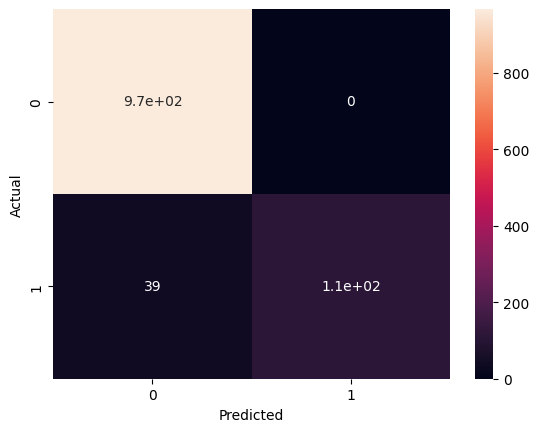

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model = MultinomialNB()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
import pickle

pickle.dump(model,open("spam_model.pkl","wb"))